In [42]:
# ============================================================
# Pipeline Data Augmentation — COCO (CVAT) + Albumentations
# Annotations en format MASQUE (RLE) exportées depuis CVAT
# ============================================================

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import cv2
import numpy as np
import albumentations as A
import os
from skimage import io

In [59]:
# ----------------------------------------------------------
# Chemins et initialisation
# ----------------------------------------------------------
ANNOTATIONS_PATH = "train_set1/annotations/instances_default.json"
IMAGES_DIR       = "train_set1/images/"
OUTPUT_DIR       = "train_set1/augmented_images/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

coco = COCO(ANNOTATIONS_PATH)
img_ids = coco.getImgIds()

# print(coco.imgs) # affiches informations sur les images (dict)
# print(len(coco.anns)) # nombre d'annotations
# print(coco.cats) # categories de labels (ici 4)
# print(img_ids) # id de toutes les images du dossier

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [29]:
# ----------------------------------------------------------
# Fonction utilitaire : décodage d'un masque RLE. Obligatoire dans notre cas car les masques ne sont pas des polygones mais codés en RLE
# ce qui pose problème pour la data augmentation, les masks ne vont pas suivrent les images. Dû à l'usage de l'outil baguette de cvat.ia qui utilise l'algo sam2/3
# ----------------------------------------------------------
def decode_mask(ann, img_height, img_width):
    """
    Décode une annotation COCO (masque RLE) en tableau binaire numpy.
    Compatible avec toutes les versions de pycocotools.
    """
    seg = ann["segmentation"]

    if isinstance(seg, dict):
        if isinstance(seg["counts"], list):
            rle = coco_mask.frPyObjects(
                [seg],
                img_height,
                img_width
            )
            rle = coco_mask.merge(rle)
        else:
            rle = seg
        decoded = coco_mask.decode(rle)

    elif isinstance(seg, list):
        rle = coco_mask.frPyObjects(seg, img_height, img_width)
        rle = coco_mask.merge(rle)
        decoded = coco_mask.decode(rle)

    else:
        print(f"⚠️  Format segmentation inconnu pour annotation {ann['id']}")
        return np.zeros((img_height, img_width), dtype=np.uint8)

    if decoded.ndim == 3:
        decoded = decoded.max(axis=2)

    return decoded.astype(np.uint8)

### Recuparation images with mask (containing labels)

In [60]:
# ----------------------------------------------------------
# Boucle principale
# ----------------------------------------------------------
for img_id in img_ids:

    img_info = coco.loadImgs(img_id)[0]
    img = cv2.imread(os.path.join(IMAGES_DIR, img_info["file_name"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_info["height"], img_info["width"]

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns    = coco.loadAnns(ann_ids)

    # Construction du masque multi-classe
    mask = np.zeros((h, w), dtype=np.uint8)  # 0 = fond
    for ann in anns:
        binary_mask = decode_mask(ann, h, w)
        mask[binary_mask == 1] = ann["category_id"]

    # Sauvegarde
    base = os.path.splitext(img_info["file_name"])[0]
    cv2.imwrite(
        f"{OUTPUT_DIR}{base}.jpg",
        cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    )
    cv2.imwrite(f"{OUTPUT_DIR}{base}_mask.png", mask)
    # ⚠️  PNG obligatoire pour le masque (lossless) — JPEG interdit

print("Récupération des images et masks terminée !")

Récupération des images et masks terminée !


### Data augmentation

In [26]:
# ----------------------------------------------------------
# Pipeline d'augmentation with Albumentations library
# ----------------------------------------------------------
transform = A.Compose([
    A.Rotate(limit=45, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.3),
    A.RandomScale(scale_limit=0.2, p=0.5),
])

In [61]:
# ----------------------------------------------------------
# Boucle principale
# ----------------------------------------------------------
for img_id in img_ids:

    img_info = coco.loadImgs(img_id)[0]
    img = cv2.imread(os.path.join(IMAGES_DIR, img_info["file_name"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_info["height"], img_info["width"]

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns    = coco.loadAnns(ann_ids)

    # Construction du masque multi-classe
    mask = np.zeros((h, w), dtype=np.uint8)  # 0 = fond
    for ann in anns:
        binary_mask = decode_mask(ann, h, w)
        mask[binary_mask == 1] = ann["category_id"]

    # Application de l'augmentation (identique au pipeline original)
    result   = transform(image=img, mask=mask)
    aug_img  = result["image"]
    aug_mask = result["mask"]

    # Sauvegarde
    base = os.path.splitext(img_info["file_name"])[0]
    cv2.imwrite(
        f"{OUTPUT_DIR}{base}_aug.jpg",
        cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
    )
    cv2.imwrite(f"{OUTPUT_DIR}{base}_aug_mask.png", aug_mask)
    # ⚠️  PNG obligatoire pour le masque (lossless) — JPEG interdit

print("Augmentation terminée !")

Augmentation terminée !


### Vérification des masques

[0 1 3 4]
AxesImage(shape=(3000, 4000))


C:\Users\benji\AppData\Local\Temp\ipykernel_26340\408856839.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  print(io.imshow(mask))
c:\Users\benji\anaconda3\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


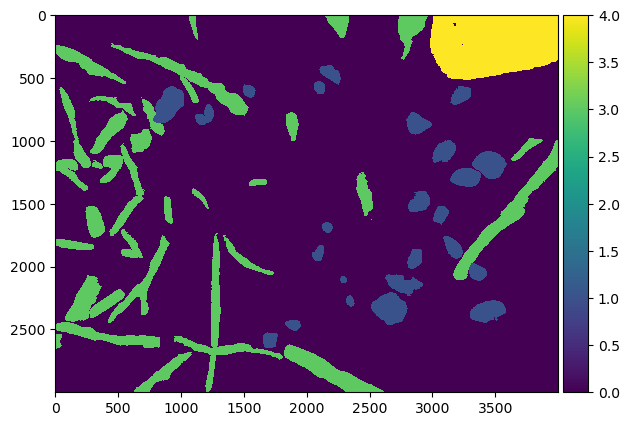

In [62]:
# On vérifie en affichant les valeurs uniques des masks qu'elles sont bien comprises entre 0 (rien) et 4 (target)
mask = io.imread("train_set1/augmented_images/G0013008_mask.png")
print(np.unique(mask))
print(io.imshow(mask))